In [3]:
# ============================================================
# W8 CELL 1 — LOAD DATA AND CHECK XGBOOST + SHAP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer

# Check required libraries
try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
except ImportError:
    print("XGBoost is not installed.")

try:
    import shap
    print("SHAP version:", shap.__version__)
except ImportError:
    print("SHAP is not installed.")

# Load feature-engineered data
train_fe = pd.read_csv("../data/train_fe_w6.csv")
test_fe = pd.read_csv("../data/test_fe_w6.csv")

# Restore Date
train_fe["Date"] = pd.to_datetime(train_fe["Date"])
test_fe["Date"] = pd.to_datetime(test_fe["Date"])

print("\nData loaded successfully.")
print("Training shape:", train_fe.shape)
print("Test shape:", test_fe.shape)

print("\nTraining dates:")
print(train_fe["Date"].min(), "to", train_fe["Date"].max())

print("\nTest dates:")
print(test_fe["Date"].min(), "to", test_fe["Date"].max())

XGBoost version: 3.4.1
SHAP version: 0.52.0

Data loaded successfully.
Training shape: (15636, 22)
Test shape: (8681, 22)

Training dates:
2015-01-02 00:00:00 to 2019-05-25 00:00:00

Test dates:
2019-05-26 00:00:00 to 2020-06-30 00:00:00


In [4]:
# ============================================================
# W8 CELL 2 — INSTALL XGBOOST AND SHAP
# ============================================================

%pip install xgboost shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# ============================================================
# W8 CELL 3 — PREPARE TARGET AND FEATURES
# ============================================================

HAZARDOUS_THRESHOLD = 301
TARGET = "Hazardous_Tomorrow"

# Create target
train_fe[TARGET] = (
    train_fe["Tomorrow_AQI"] >= HAZARDOUS_THRESHOLD
).astype(int)

test_fe[TARGET] = (
    test_fe["Tomorrow_AQI"] >= HAZARDOUS_THRESHOLD
).astype(int)

# Same clean features used in W6 and W7
EXCLUDE_COLUMNS = [
    "City",
    "Date",
    "Tomorrow_AQI",
    "Hazardous_Tomorrow",
    "AQI_Bucket",
    "AQI"                  # duplicate of AQI_Current
]

XGB_FEATURES = [
    col for col in train_fe.columns
    if col not in EXCLUDE_COLUMNS
]

X_train_xgb = train_fe[XGB_FEATURES].copy()
X_test_xgb = test_fe[XGB_FEATURES].copy()

y_train_xgb = train_fe[TARGET].copy()
y_test_xgb = test_fe[TARGET].copy()

print("XGBoost features prepared.")

print("\nNumber of features:", len(XGB_FEATURES))
print(XGB_FEATURES)

print("\nTraining shape:", X_train_xgb.shape)
print("Test shape:", X_test_xgb.shape)

print("\nTarget distribution:")
print("Training:")
print(y_train_xgb.value_counts().sort_index())

print("\nTest:")
print(y_test_xgb.value_counts().sort_index())

print("\nMissing values:")
print("Training:", X_train_xgb.isna().sum().sum())
print("Test:", X_test_xgb.isna().sum().sum())

XGBoost features prepared.

Number of features: 17
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI_Current', 'AQI_Lag1', 'AQI_3Day_Mean', 'DayOfWeek', 'Month']

Training shape: (15636, 17)
Test shape: (8681, 17)

Target distribution:
Training:
Hazardous_Tomorrow
0    12642
1     2994
Name: count, dtype: int64

Test:
Hazardous_Tomorrow
0    8082
1     599
Name: count, dtype: int64

Missing values:
Training: 30279
Test: 12006


In [6]:
# ============================================================
# W8 CELL 4 — TRAIN BASELINE XGBOOST CLASSIFIER
# ============================================================

import xgboost as xgb

# Calculate class imbalance ratio from training data only
negative_count = (y_train_xgb == 0).sum()
positive_count = (y_train_xgb == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Scale positive weight:", round(scale_pos_weight, 4))

# Create XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Train
xgb_model.fit(
    X_train_xgb,
    y_train_xgb
)

print("\nBaseline XGBoost trained successfully.")

print("\nModel parameters:")
print("Number of trees:", xgb_model.n_estimators)
print("Maximum depth:", xgb_model.max_depth)
print("Learning rate:", xgb_model.learning_rate)
print("Min child weight:", xgb_model.min_child_weight)
print("Subsample:", xgb_model.subsample)
print("Column sample:", xgb_model.colsample_bytree)
print("Scale positive weight:", round(scale_pos_weight, 4))

Scale positive weight: 4.2224

Baseline XGBoost trained successfully.

Model parameters:
Number of trees: 300
Maximum depth: 6
Learning rate: 0.05
Min child weight: 5
Subsample: 0.8
Column sample: 0.8
Scale positive weight: 4.2224


In [8]:
# ============================================================
# W8 CELL 5 — EVALUATE BASELINE XGBOOST
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_xgb)
y_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

# Metrics
xgb_accuracy = accuracy_score(y_test_xgb, y_pred_xgb)

xgb_precision = precision_score(
    y_test_xgb,
    y_pred_xgb,
    zero_division=0
)

xgb_recall = recall_score(
    y_test_xgb,
    y_pred_xgb,
    zero_division=0
)

xgb_f1 = f1_score(
    y_test_xgb,
    y_pred_xgb,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_test_xgb,
    y_prob_xgb
)

print("BASELINE XGBOOST — TEST RESULTS")
print("=" * 50)
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_xgb,
    y_pred_xgb
))

print("\nClassification Report:")
print(classification_report(
    y_test_xgb,
    y_pred_xgb,
    target_names=["Non-hazardous", "Hazardous"],
    zero_division=0
))

BASELINE XGBOOST — TEST RESULTS
Accuracy : 0.9783
Precision: 0.8118
Recall   : 0.8932
F1 Score : 0.8506
ROC-AUC  : 0.9918

Confusion Matrix:
[[7958  124]
 [  64  535]]

Classification Report:
               precision    recall  f1-score   support

Non-hazardous       0.99      0.98      0.99      8082
    Hazardous       0.81      0.89      0.85       599

     accuracy                           0.98      8681
    macro avg       0.90      0.94      0.92      8681
 weighted avg       0.98      0.98      0.98      8681



In [9]:
# ============================================================
# W8 CELL 6 — LEAKAGE-FREE XGBOOST TUNING
# ============================================================

from sklearn.model_selection import TimeSeriesSplit

# Training data only
X_cv_xgb = train_fe[XGB_FEATURES].copy()
y_cv_xgb = train_fe[TARGET].copy()

# Chronological unique dates
unique_dates_xgb = np.sort(
    train_fe["Date"].unique()
)

tscv_xgb = TimeSeriesSplit(n_splits=5)

# Small, controlled parameter grid
xgb_configs = [
    {"max_depth": 4, "learning_rate": 0.05, "min_child_weight": 5},
    {"max_depth": 6, "learning_rate": 0.05, "min_child_weight": 5},
    {"max_depth": 8, "learning_rate": 0.05, "min_child_weight": 5},
    {"max_depth": 6, "learning_rate": 0.03, "min_child_weight": 5},
    {"max_depth": 6, "learning_rate": 0.05, "min_child_weight": 10}
]

xgb_cv_results = []

# Class imbalance ratio from TRAINING DATA ONLY
negative_count = (y_cv_xgb == 0).sum()
positive_count = (y_cv_xgb == 1).sum()
cv_scale_pos_weight = negative_count / positive_count

for config in xgb_configs:

    fold_f1 = []
    fold_recall = []

    for train_date_idx, val_date_idx in tscv_xgb.split(unique_dates_xgb):

        train_dates = unique_dates_xgb[train_date_idx]
        val_dates = unique_dates_xgb[val_date_idx]

        train_mask = train_fe["Date"].isin(train_dates)
        val_mask = train_fe["Date"].isin(val_dates)

        X_fold_train = X_cv_xgb.loc[train_mask]
        X_fold_val = X_cv_xgb.loc[val_mask]

        y_fold_train = y_cv_xgb.loc[train_mask]
        y_fold_val = y_cv_xgb.loc[val_mask]

        # XGBoost handles missing values natively
        model = xgb.XGBClassifier(
            n_estimators=200,
            max_depth=config["max_depth"],
            learning_rate=config["learning_rate"],
            min_child_weight=config["min_child_weight"],
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=cv_scale_pos_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            X_fold_train,
            y_fold_train
        )

        pred = model.predict(X_fold_val)

        fold_f1.append(
            f1_score(y_fold_val, pred, zero_division=0)
        )

        fold_recall.append(
            recall_score(y_fold_val, pred, zero_division=0)
        )

    xgb_cv_results.append({
        "Max_Depth": config["max_depth"],
        "Learning_Rate": config["learning_rate"],
        "Min_Child_Weight": config["min_child_weight"],
        "Mean_CV_F1": np.mean(fold_f1),
        "SE_F1": (
            np.std(fold_f1, ddof=1)
            / np.sqrt(len(fold_f1))
        ),
        "Mean_CV_Recall": np.mean(fold_recall)
    })

xgb_cv_results = pd.DataFrame(xgb_cv_results)

print("LEAKAGE-FREE XGBOOST CV RESULTS")
print("=" * 90)

print(
    xgb_cv_results
    .sort_values("Mean_CV_F1", ascending=False)
    .to_string(index=False)
)

LEAKAGE-FREE XGBOOST CV RESULTS
 Max_Depth  Learning_Rate  Min_Child_Weight  Mean_CV_F1    SE_F1  Mean_CV_Recall
         6           0.05                10    0.852083 0.010173        0.905407
         8           0.05                 5    0.851509 0.010336        0.880754
         6           0.03                 5    0.851167 0.010544        0.907611
         4           0.05                 5    0.849352 0.010780        0.906029
         6           0.05                 5    0.847317 0.010784        0.887037


In [10]:
# ============================================================
# W8 CELL 7 — TRAIN FINAL XGBOOST
# ============================================================

FINAL_XGB_DEPTH = 4
FINAL_XGB_LEARNING_RATE = 0.05
FINAL_XGB_MIN_CHILD_WEIGHT = 5

final_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=FINAL_XGB_DEPTH,
    learning_rate=FINAL_XGB_LEARNING_RATE,
    min_child_weight=FINAL_XGB_MIN_CHILD_WEIGHT,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Train on complete training data
final_xgb.fit(
    X_train_xgb,
    y_train_xgb
)

print("Final XGBoost trained successfully.")

print("\nFinal parameters:")
print("Number of trees:", final_xgb.n_estimators)
print("Maximum depth:", final_xgb.max_depth)
print("Learning rate:", final_xgb.learning_rate)
print("Min child weight:", final_xgb.min_child_weight)
print("Subsample:", final_xgb.subsample)
print("Column sample:", final_xgb.colsample_bytree)
print("Scale positive weight:", round(scale_pos_weight, 4))

Final XGBoost trained successfully.

Final parameters:
Number of trees: 300
Maximum depth: 4
Learning rate: 0.05
Min child weight: 5
Subsample: 0.8
Column sample: 0.8
Scale positive weight: 4.2224


In [11]:
# ============================================================
# W8 CELL 8 — FINAL XGBOOST TEST EVALUATION
# ============================================================

# Final predictions
y_pred_xgb_final = final_xgb.predict(X_test_xgb)
y_prob_xgb_final = final_xgb.predict_proba(X_test_xgb)[:, 1]

# Metrics
final_xgb_accuracy = accuracy_score(
    y_test_xgb, y_pred_xgb_final
)

final_xgb_precision = precision_score(
    y_test_xgb,
    y_pred_xgb_final,
    zero_division=0
)

final_xgb_recall = recall_score(
    y_test_xgb,
    y_pred_xgb_final,
    zero_division=0
)

final_xgb_f1 = f1_score(
    y_test_xgb,
    y_pred_xgb_final,
    zero_division=0
)

final_xgb_roc_auc = roc_auc_score(
    y_test_xgb,
    y_prob_xgb_final
)

print("FINAL XGBOOST — TEST RESULTS")
print("=" * 50)
print(f"Accuracy : {final_xgb_accuracy:.4f}")
print(f"Precision: {final_xgb_precision:.4f}")
print(f"Recall   : {final_xgb_recall:.4f}")
print(f"F1 Score : {final_xgb_f1:.4f}")
print(f"ROC-AUC  : {final_xgb_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_xgb,
    y_pred_xgb_final
))

print("\nClassification Report:")
print(classification_report(
    y_test_xgb,
    y_pred_xgb_final,
    target_names=["Non-hazardous", "Hazardous"],
    zero_division=0
))

FINAL XGBOOST — TEST RESULTS
Accuracy : 0.9751
Precision: 0.7649
Recall   : 0.9232
F1 Score : 0.8366
ROC-AUC  : 0.9919

Confusion Matrix:
[[7912  170]
 [  46  553]]

Classification Report:
               precision    recall  f1-score   support

Non-hazardous       0.99      0.98      0.99      8082
    Hazardous       0.76      0.92      0.84       599

     accuracy                           0.98      8681
    macro avg       0.88      0.95      0.91      8681
 weighted avg       0.98      0.98      0.98      8681



Creating SHAP explainer...
Calculating SHAP values...
SHAP analysis completed successfully.
Samples explained: 1000
SHAP value shape: (1000, 17)


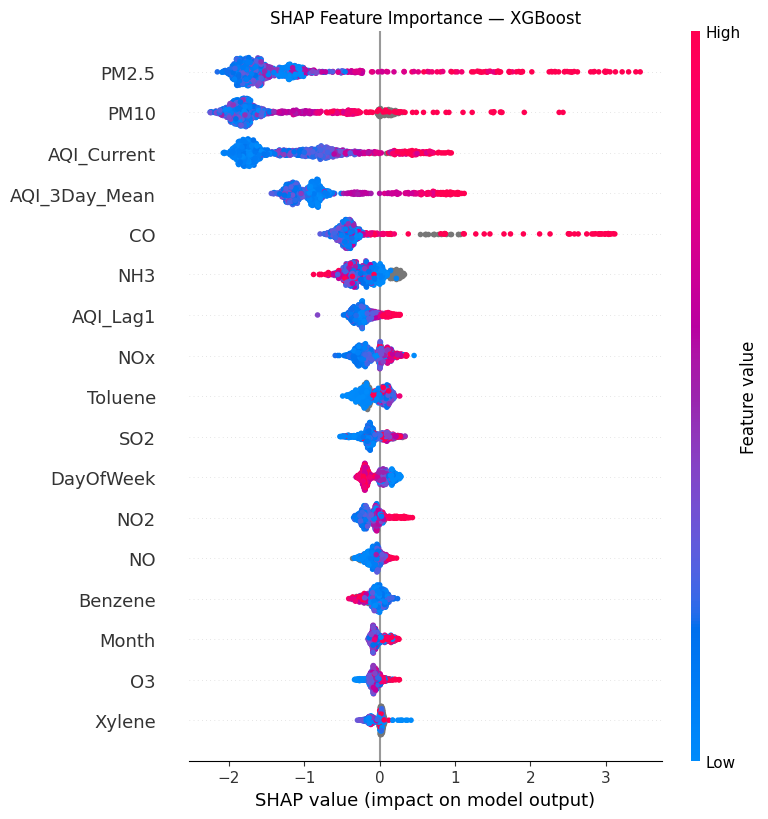

In [12]:
# ============================================================
# W8 CELL 9 — SHAP FEATURE IMPORTANCE
# ============================================================

import shap

print("Creating SHAP explainer...")

# TreeExplainer is designed for tree-based models
explainer = shap.TreeExplainer(final_xgb)

# Use a manageable sample of the test set for explanation
SHAP_SAMPLE_SIZE = min(1000, len(X_test_xgb))

X_shap = X_test_xgb.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=42
)

print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_shap)

print("SHAP analysis completed successfully.")
print("Samples explained:", len(X_shap))

# Handle SHAP output shape
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

print("SHAP value shape:", np.array(shap_values_plot).shape)

# SHAP summary plot
plt.figure()

shap.summary_plot(
    shap_values_plot,
    X_shap,
    show=False
)

plt.title("SHAP Feature Importance — XGBoost")
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# W8 CELL 10 — SAVE SHAP RESULTS
# ============================================================

import os

os.makedirs("../data", exist_ok=True)

# Calculate mean absolute SHAP importance
shap_importance = pd.DataFrame({
    "Feature": XGB_FEATURES,
    "Mean_Absolute_SHAP": np.abs(
        shap_values_plot
    ).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

# Save importance table
shap_importance.to_csv(
    "../data/w8_shap_feature_importance.csv",
    index=False
)

# Save SHAP summary plot
plt.figure()

shap.summary_plot(
    shap_values_plot,
    X_shap,
    show=False
)

plt.title("SHAP Feature Importance — XGBoost")
plt.tight_layout()

plt.savefig(
    "../data/w8_xgboost_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("SHAP results saved successfully.")

print("\nTop SHAP Features:")
print(
    shap_importance.head(10).to_string(index=False)
)

print("\nFiles saved:")
print("1. w8_shap_feature_importance.csv")
print("2. w8_xgboost_shap_summary.png")

SHAP results saved successfully.

Top SHAP Features:
      Feature  Mean_Absolute_SHAP
        PM2.5            1.518895
         PM10            1.447699
  AQI_Current            1.207557
AQI_3Day_Mean            0.931556
           CO            0.500156
          NH3            0.248542
     AQI_Lag1            0.221384
          NOx            0.173410
      Toluene            0.151564
          SO2            0.147588

Files saved:
1. w8_shap_feature_importance.csv
2. w8_xgboost_shap_summary.png
